### M-DART: SUPPFIG 1 AND STATS

In [1]:
import os
import pandas as pd
import numpy as np
from scipy import stats
from pathlib import Path
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

plt.rcParams['pdf.fonttype'] = 42  # To embed fonts in PDF output (for Illustrator compatibility)
plt.rcParams['font.family'] = 'Arial'

In [2]:
# ---- Helpers for plotting ----
def p_to_stars(p: float, show_ns: bool = False) -> str:
    """Convert p-value to significance stars."""
    
    if p is None or np.isnan(p):
        return ""

    # threshold : star label
    p_dict = {
        1e-4: "****",    # p < 0.0001
        1e-3: "***",     # p < 0.001
        1e-2: "**",      # p < 0.01
        5e-2: "*",       # p < 0.05
    }

    # iterate in ascending order of thresholds
    for threshold in sorted(p_dict):
        if p < threshold:
            return p_dict[threshold]

    return "ns" if show_ns else ""

def _draw_contrast(ax, x1, x2, y, stars,
                   line_lw=0.45, star_fs=6,
                   star_pad_pts=1.5,   # <-- NEW: star offset in points
                   y_pad_frac=0.0):    # optional: additional offset as fraction of y-range
    """
    Draw a single contrast bracket and star label.

    star_pad_pts: vertical gap between the line and the stars in points (recommended control).
    y_pad_frac:   additional vertical gap in data units as fraction of y-range (optional).
    """
    # Get y-range for optional fractional padding
    ymin, ymax = ax.get_ylim()
    yr = ymax - ymin

    # Draw the bracket line
    ax.plot([x1, x1, x2, x2], [y, y, y, y], lw=line_lw, c="black")

    # Place stars: right above the line
    x_mid = (x1 + x2) / 2.0
    y_star = y + y_pad_frac * yr

    ax.annotate(
        stars,
        xy=(x_mid, y_star),
        xytext=(0, star_pad_pts),  # <-- gap above line, in points
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=star_fs,
    )

def add_contrast_lines_and_stars(ax, comparisons,
    y_base=None,
    base_pad_frac=0.09,
    step_frac=0.12,
    line_lw=0.45,
    star_fs=6,
    star_pad_pts=1.5,  # <-- NEW
    y_pad_frac=0.0,    # keep if you want (I’d default to 0 now)
    expand_ylim=True,):
    """
    Draw ONE OR MULTIPLE contrast lines + stars on a bar plot.

    Parameters
    ----------
    comparisons:
        Either:
          - a single tuple (x1, x2, stars)
          - OR a list/iterable of tuples [(x1, x2, stars), ...]
        `x1` and `x2` are x-locations (bar centers), `stars` is a string (e.g., "*", "ns", "").

    y_base: Where to start stacking lines (in data units). If None, it auto-detects the tallest bar.

    base_pad_frac: Fraction of y-axis range to add above y_base for the first line.

    step_frac: Fraction of y-axis range added per additional comparison line.

    expand_ylim: If True, expands y-limits upward so the top stars are not clipped.
    """

    # Filter out empty star entries
    comps = [(x1, x2, s) for (x1, x2, s) in comparisons if s]
    if not comps:
        return

    # Get current y-range to convert fractions into data units
    ymin, ymax = ax.get_ylim()
    yr = ymax - ymin

    # Auto-pick y_base if not provided
    if y_base is None:
        bar_tops = [p.get_height() for p in ax.patches]
        # If there are bars, start above the tallest bar. Otherwise fall back to ymax.
        y_base = max(bar_tops) if bar_tops else ymax

    # First line starts at y0, above y_base by base_pad_frac of the y-range.
    y0 = y_base + base_pad_frac * yr

    # Draw each comparison, stacking vertically with step_frac spacing
    for i, (x1, x2, stars) in enumerate(comps):
        y = y0 + i * step_frac * yr
        _draw_contrast(
            ax=ax, x1=x1, x2=x2, y=y, stars=stars,
            line_lw=line_lw, star_fs=star_fs, y_pad_frac=y_pad_frac, star_pad_pts=star_pad_pts
        )

    # Optionally expand y-limits so stars aren’t clipped
    if expand_ylim:
        # The highest line is the last one: i = len(comps)-1
        top_line_y = y0 + (len(comps) - 1) * step_frac * yr

        # Add extra headroom for the text above that line.
        top_needed = top_line_y + (y_pad_frac + 0.03) * yr

        if top_needed > ymax:
            ax.set_ylim(ymin, top_needed)

def _style_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(0.4)
    ax.spines["left"].set_linewidth(0.4)
    ax.tick_params(axis="both", which="both", width=0.4)

def save_figure(
    fig,
    out_dir,
    filename,
    dpi=600,
    save_pdf=True,
    save_png=True,
    facecolor="white",
    bbox_inches="tight",
):
    """ Save figure in PDF and PNG format."""

    if save_pdf:
        fig.savefig(
            os.path.join(out_dir, f"{filename}.pdf"),
            bbox_inches=bbox_inches,
        )

    if save_png:
        fig.savefig(
            os.path.join(out_dir, f"{filename}.png"),
            dpi=dpi,
            bbox_inches=bbox_inches,
            facecolor=facecolor,
        )

# -----------------------------
# Plotting constants
# -----------------------------
colors_dict1 = {
    "p_risk": "#ff5aa7",   # pink
    "r_risk": "#d98c00",   # orange
    "a_amb":  "#9fd3e6",   # light blue
}

order = ["p_risk", "r_risk", "a_amb"]
regressor_labels = {"p_risk": "Probability", "r_risk": "Risk", "a_amb": "Ambiguity"}

In [3]:
data_dir = Path("../data/figure1")
fig_out_dir = Path(r"C:\Users\psiok\Box\3.Projects\3.MDART-Paper\MDART_Analyses\outputs\figures")

beh_df = pd.read_csv(data_dir / "behavioral_data.csv")
print(beh_df.shape)

(13736, 30)


#### Supplementary Figure 1, Panel a-b:

In [4]:
# ----------------------------
# Data preparation
# ----------------------------
certain_trials = beh_df.loc[beh_df["TrialType"] == "certain"].copy()

def _certain_summary(df, ycol):
    """Subject-level means → group summary with SEM and 95% CI."""
    df_subj = (
        df.dropna(subset=[ycol])
        .groupby(["subject", "p_risk"], as_index=False)[ycol]
        .mean()
    )
    summ = (
        df_subj.groupby("p_risk")[ycol]
        .agg(mean="mean", std="std", n="count")
        .reset_index()
        .sort_values("p_risk")
    )
    summ["sem"] = summ["std"] / np.sqrt(summ["n"])
    tval = stats.t.ppf(0.975, df=summ["n"] - 1)
    summ["ci95"] = tval * summ["sem"]
    return summ

summ_rating = _certain_summary(certain_trials, "RatingValue")
summ_scl    = _certain_summary(certain_trials, "scr_zscored")

# ----------------------------
# Plot functions
# ----------------------------
certain_colors = ["#333333", "red"]

def _plot_certain_base(ax, summ, ylabel, colors, p_value, annotate, show_ns):
    """Shared plotting logic for certain-trial bar panels."""
    x = np.arange(len(summ))
    labels = [f"{int(v)}%" for v in summ["p_risk"]]

    ax.bar(x, summ["mean"], color=colors, width=0.7, edgecolor="none")
    ax.errorbar(x, summ["mean"], yerr=summ["sem"],
                fmt="none", ecolor="black", linewidth=0.4, capsize=1, capthick=0.4)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=5.5, fontdict={"family": "Arial"})
    ax.set_xlabel("Probability of Threat", fontsize=5.5, labelpad=1.5, fontdict={"family": "Arial"})
    ax.set_ylabel(ylabel, fontsize=5.5, labelpad=1, fontdict={"family": "Arial"})
    ax.tick_params(axis="both", labelsize=5.5, pad=0.5)
    ax.axhline(0, color="black", linewidth=0.4)
    ax.margins(x=0.02, y=0.02)
    _style_axes(ax)

    if annotate and p_value is not None:
        stars = p_to_stars(p_value, show_ns=show_ns)
        x1, x2 = float(x[0]), float(x[1])
        tops = summ["mean"].to_numpy() + summ["ci95"].to_numpy()
        ymin, ymax = ax.get_ylim()
        y_line = float(np.max(tops)) + (ymax - ymin) * 0.05
        add_contrast_lines_and_stars(ax, [(x1, x2, stars)], y_base=y_line)

def plot_certain_rating_panel(ax, summ, colors, p_value=None,
                               annotate=True, show_ns=False):
    _plot_certain_base(ax, summ, "Distress Rating", colors, p_value, annotate, show_ns)
    #add_panel_label(ax, "a", x=-0.17, y=1.09)


def plot_certain_scl_panel(ax, summ, colors, p_value=None,
                            annotate=True, show_ns=False):
    _plot_certain_base(ax, summ, "SCR", colors, p_value, annotate, show_ns)
    #add_panel_label(ax, "b", x=-0.17, y=1.09)

##### Statistics of Supplementary Figure 1, Panel a-b:

In [5]:
certain_trials = beh_df[beh_df['TrialType']=='certain']
certain_trials_rating = certain_trials[['RatingValue', 'ThreatPct', 'p_risk', 'subject']].dropna()
certain_trials_rating["p_threat"] = certain_trials_rating["p_risk"].map({0:"safe", 100:"threat"})

certain_trials_rating["p_threat"] = pd.Categorical(
    certain_trials_rating["p_threat"],
    categories=["safe", "threat"],
    ordered=False
)

mdl_Sfig1_a = smf.mixedlm(
    "RatingValue ~ C(p_threat)",
    data=certain_trials_rating,
    groups=certain_trials_rating["subject"]
).fit()

print(mdl_Sfig1_a.summary())

# Panel a's own p-value (safe vs. threat), used for the significance stars on this panel.
p_Sfig1_a = mdl_Sfig1_a.pvalues["C(p_threat)[T.threat]"]
print("p_Sfig1_a:", p_Sfig1_a)

             Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   RatingValue
No. Observations:    2825      Method:               REML       
No. Groups:          101       Scale:                0.8379     
Min. group size:     26        Log-Likelihood:       -3904.9272 
Max. group size:     28        Converged:            Yes        
Mean group size:     28.0                                       
----------------------------------------------------------------
                      Coef. Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept             0.295    0.073   4.029 0.000  0.151  0.438
C(p_threat)[T.threat] 4.419    0.034 128.293 0.000  4.351  4.487
Group Var             0.480    0.080                            

p_Sfig1_a: 0.0


In [6]:
certain_trials = beh_df[beh_df['TrialType']=='certain']
certain_trials_scl = certain_trials[['scr_zscored', 'ThreatPct', 'p_risk', 'subject']].dropna()
certain_trials_scl["p_threat"] = certain_trials_scl["p_risk"].map({0:"safe", 100:"threat"})

certain_trials_scl["p_threat"] = pd.Categorical(
    certain_trials_scl["p_threat"],
    categories=["safe", "threat"],
    ordered=False
)

mdl_Sfig1_b = smf.mixedlm(
    "scr_zscored ~ C(p_threat)",
    data=certain_trials_scl,
    groups=certain_trials_scl["subject"]
).fit()

print(mdl_Sfig1_b.summary())

# Panel b's own p-value (safe vs. threat), used for the significance stars on this panel.
p_Sfig1_b = mdl_Sfig1_b.pvalues["C(p_threat)[T.threat]"]
print("p_Sfig1_b:", p_Sfig1_b)

C:\Users\psiok\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\psiok\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\psiok\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\psiok\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(


              Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   scr_zscored
No. Observations:     3492      Method:               REML       
No. Groups:           97        Scale:                1.1057     
Min. group size:      36        Log-Likelihood:       -5141.9026 
Max. group size:      36        Converged:            No         
Mean group size:      36.0                                       
-----------------------------------------------------------------
                      Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept             -0.285    0.026 -10.913 0.000 -0.336 -0.234
C(p_threat)[T.threat]  0.897    0.036  25.215 0.000  0.828  0.967
Group Var              0.005    0.009                            

p_Sfig1_b: 2.7395150072519833e-140


C:\Users\psiok\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\psiok\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\psiok\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 68.759060
  warnings.warn(msg, ConvergenceWarning)
C:\Users\psiok\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


#### Supplementary Figure 1, Panel d-e:

In [7]:
# -------------------------
# Config
# -------------------------
order_cat = ["CertainThreat_vs_CertainSafe", "UncertainThreat_vs_CertainThreat", "Amb_vs_Risk"]
regressor_labels_cat = {
    "CertainThreat_vs_CertainSafe":     "Certain Threat\n vs.\nCertain Safe",
    "UncertainThreat_vs_CertainThreat": "Uncertain Threat\n vs.\nCertain Threat",
    "Amb_vs_Risk":                      "Ambiguous\n vs.\nUnambiguous",
}

col_1 = "#e91212"
col_2 = "#ff9900"
col_3 = "#0000ff"
colors_cat = {
    "CertainThreat_vs_CertainSafe":     col_1,
    "UncertainThreat_vs_CertainThreat": col_2,
    "Amb_vs_Risk":                      col_3,
}

# -------------------------
# Data loading
# -------------------------
csv_path = "../data/suppfig1/signature_expression_categorical_contrasts.csv"
fig_out_dir_cd = os.path.dirname(csv_path)

categorical_sig_df = pd.read_csv(csv_path)
categorical_sig_df["subject"]   = categorical_sig_df["subject"].astype(str)
categorical_sig_df["regressor"] = categorical_sig_df["regressor"].astype(str)
categorical_sig_df["signature"] = categorical_sig_df["signature"].astype(str)
cat_sig_df = categorical_sig_df[categorical_sig_df["regressor"].isin(order_cat)].copy()

SIG1 = "Ceko_NE"
SIG2 = "LiuBecker_Amb"

# -------------------------
# Data preparation
# -------------------------
def summarize_signature_df(df, signature_name, ycol="score"):
    """Subject-level means → group summary with SEM and 95% CI, ordered by order_cat."""
    sub_df  = df[df["signature"] == signature_name].copy()
    df_subj = sub_df.groupby(["subject", "regressor"], as_index=False)[ycol].mean()
    summ = (
        df_subj.groupby("regressor")[ycol]
        .agg(mean="mean", std="std", n="count")
        .reset_index()
    )
    summ["sem"]  = summ["std"] / np.sqrt(summ["n"])
    tval         = stats.t.ppf(0.975, df=summ["n"] - 1)
    summ["ci95"] = tval * summ["sem"]
    summ["regressor"] = pd.Categorical(summ["regressor"], categories=order_cat, ordered=True)
    return summ.sort_values("regressor").reset_index(drop=True)

cat_summ_Ceko_NE       = summarize_signature_df(cat_sig_df, SIG1, ycol="score")
cat_summ_LiuBecker_Amb = summarize_signature_df(cat_sig_df, SIG2, ycol="score")

# -------------------------
# Plot functions
# -------------------------
def _plot_signature_base(ax, summ, colors, ylabel, title,
                          p_1_vs_2=None, p_1_vs_3=None, add_contrasts=True, ylim=None, yticks=None):
    x_keys = summ["regressor"].astype(str).values
    x      = np.arange(len(x_keys))
    y      = summ["mean"].values
    errbar = summ["sem"].values

    ax.bar(x, y, width=0.55, color=[colors[r] for r in x_keys], edgecolor="none")
    ax.errorbar(x, y, yerr=errbar, fmt="none", ecolor="black",
                linewidth=0.4, capsize=1, capthick=0.4)

    ax.set_ylabel(ylabel, fontsize=5.5, labelpad=1, fontdict={"family": "Arial"})
    ax.set_title(title, fontsize=6, fontdict={"family": "Arial"}, pad=7)
    ax.tick_params(axis="y", labelsize=5.5, pad=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(
        [regressor_labels_cat.get(k, k) for k in x_keys],
        fontsize=5, fontdict={"family": "Arial"},
        rotation=0
    )

    ax.tick_params(axis="x", pad=1.5, labelbottom=True)
    ax.margins(x=0.02, y=0.02)

    ax.axhline(0, color="black", linewidth=0.4)
    _style_axes(ax)

    if ylim is not None:
        ax.set_ylim(ylim)
    if yticks is not None:
        ax.set_yticks(yticks)
        ax.set_yticklabels([f"{v}" for v in yticks],
                           fontsize=5.5, fontdict={"family": "Arial"})

    if add_contrasts and p_1_vs_2 is not None and p_1_vs_3 is not None:
        add_contrast_lines_and_stars(
            ax,
            comparisons=[
                (0, 1, p_to_stars(p_1_vs_2)),
                (0, 2, p_to_stars(p_1_vs_3)),
            ],
            base_pad_frac=0.15,
            step_frac=0.10,
            line_lw=0.4,
            star_fs=6.5,
            y_pad_frac=0.001,
            star_pad_pts=0.02,
            expand_ylim=False,
        )


def plot_Ceko_NE_panel(ax, summ, colors, p_1_vs_2=None, p_1_vs_3=None, add_contrasts=True):
    _plot_signature_base(ax, summ, colors,
                         ylabel="Signature prediction (a.u.)",
                         title=r"Negative Affect Signature$^{9}$",
                         p_1_vs_2=p_1_vs_2, p_1_vs_3=p_1_vs_3,
                         add_contrasts=add_contrasts)

    #add_panel_label(ax, "c", x=-0.17, y=1.15)


def plot_LiuBecker_panel(ax, summ, colors,
                          p_1_vs_2=None, p_1_vs_3=None, add_contrasts=True):
    _plot_signature_base(ax, summ, colors,
                         ylabel="Signature prediction (a.u.)",
                         title=r"Anticipatory Anxiety Signature$^{10}$",
                         p_1_vs_2=p_1_vs_2, p_1_vs_3=p_1_vs_3,
                         add_contrasts=add_contrasts)
    #add_panel_label(ax, "d", x=-0.17, y=1.15)

##### Statistics of Supplementary Figure 1, Panel d-e:

In [8]:
Ceko_cat_df = cat_sig_df[cat_sig_df["signature"] == SIG1].copy()
Ceko_cat_df["regressor"] = pd.Categorical(
    Ceko_cat_df["regressor"],
    categories=["CertainThreat_vs_CertainSafe", "UncertainThreat_vs_CertainThreat", "Amb_vs_Risk"],
    ordered=False
)

mdl_Sfig1_c = smf.mixedlm(
    "score ~ C(regressor)",
    data=Ceko_cat_df,
    groups=Ceko_cat_df["subject"]
).fit()

print(mdl_Sfig1_c.summary())

# Panel c's own p-values (CertainThreat_vs_CertainSafe is the reference level),
# used for the significance stars on this panel.
p_Sfig1_c_1_vs_2 = mdl_Sfig1_c.pvalues["C(regressor)[T.UncertainThreat_vs_CertainThreat]"]
p_Sfig1_c_1_vs_3 = mdl_Sfig1_c.pvalues["C(regressor)[T.Amb_vs_Risk]"]
print("p_Sfig1_c_1_vs_2:", p_Sfig1_c_1_vs_2)
print("p_Sfig1_c_1_vs_3:", p_Sfig1_c_1_vs_3)

C:\Users\psiok\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\psiok\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


                           Mixed Linear Model Regression Results
Model:                          MixedLM             Dependent Variable:             score   
No. Observations:               303                 Method:                         REML    
No. Groups:                     101                 Scale:                          0.0167  
Min. group size:                3                   Log-Likelihood:                 181.2095
Max. group size:                3                   Converged:                      Yes     
Mean group size:                3.0                                                         
--------------------------------------------------------------------------------------------
                                                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------------------
Intercept                                         0.225    0.013  17.500 0.000  0.200  0.250
C(reg

C:\Users\psiok\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\psiok\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [9]:
Liu_cat_df = cat_sig_df[cat_sig_df["signature"] == SIG2].copy()
Liu_cat_df["regressor"] = pd.Categorical(
    Liu_cat_df["regressor"],
    categories=["CertainThreat_vs_CertainSafe", "UncertainThreat_vs_CertainThreat", "Amb_vs_Risk"],
    ordered=False
)

mdl_Sfig1_d = smf.mixedlm(
    "score ~ C(regressor)",
    data=Liu_cat_df,
    groups=Liu_cat_df["subject"]
).fit()

print(mdl_Sfig1_d.summary())

# Panel d's own p-values (CertainThreat_vs_CertainSafe is the reference level),
# used for the significance stars on this panel.
p_Sfig1_d_1_vs_2 = mdl_Sfig1_d.pvalues["C(regressor)[T.UncertainThreat_vs_CertainThreat]"]
p_Sfig1_d_1_vs_3 = mdl_Sfig1_d.pvalues["C(regressor)[T.Amb_vs_Risk]"]
print("p_Sfig1_d_1_vs_2:", p_Sfig1_d_1_vs_2)
print("p_Sfig1_d_1_vs_3:", p_Sfig1_d_1_vs_3)

C:\Users\psiok\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\psiok\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\psiok\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\psiok\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(


                           Mixed Linear Model Regression Results
Model:                         MixedLM             Dependent Variable:             score    
No. Observations:              303                 Method:                         REML     
No. Groups:                    101                 Scale:                          0.3623   
Min. group size:               3                   Log-Likelihood:                 -280.3438
Max. group size:               3                   Converged:                      No       
Mean group size:               3.0                                                          
--------------------------------------------------------------------------------------------
                                                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------------------
Intercept                                         1.368    0.060  22.833 0.000  1.250  1.485
C(reg

C:\Users\psiok\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\psiok\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\psiok\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 1.191568
  warnings.warn(msg, ConvergenceWarning)
C:\Users\psiok\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


#### Supplementary Figure 1, Panel f:

In [10]:
# -----------------------------
# Core helpers for signature plotting
# -----------------------------
order = ["Probability", "Risk", "Ambiguity"]
#regressor_labels = {"p_risk": "Probability", "r_risk": "Risk", "a_amb": "Ambiguity"}

col_prob = "#ff5aa7"   # pink
col_risk = "#d98c00"   # orange
col_amb  = "#9fd3e6"   # light blue
colors_by_reg = {"Probability": col_prob, "Risk": col_risk, "Ambiguity": col_amb}


def summarize_signature_df_nonCat(df_sig: pd.DataFrame, signature_name: str, ycol: str = "score") -> pd.DataFrame:
    """
    For ONE signature: subject-level mean per regressor -> group mean ± SEM and CI95.
    """
    df_sig = df_sig[df_sig["signature"] == signature_name].copy()
    if df_sig.empty:
        # ax.axis("off")
        # ax.set_title(f"{signature_name}\n(no data)")
        return None
    
    # subject-level means (guards against repeated rows per subject)
    df_subj = (
        df_sig.groupby(["subject", "regressor"], as_index=False)[ycol]
              .mean()
    )

    summ = (
        df_subj.groupby("regressor")[ycol]
               .agg(mean="mean", std="std", n="count")
               .reset_index()
    )

    summ["sem"] = summ["std"] / np.sqrt(summ["n"])

    # CI95 using t distribution (safe for n<=1)
    summ["ci95"] = 0.0
    mask = summ["n"] > 1
    if mask.any():
        tval = stats.t.ppf(0.975, df=summ.loc[mask, "n"] - 1)
        summ.loc[mask, "ci95"] = tval * summ.loc[mask, "sem"]

    # enforce order
    summ["regressor"] = pd.Categorical(summ["regressor"], categories=order, ordered=True)
    summ = summ.sort_values("regressor").reset_index(drop=True)

    # pretty labels + colors
    #summ["label"] = summ["regressor"].astype(str).map(regressor_labels)
    summ["color"] = summ["regressor"].astype(str).map(colors_by_reg)

    return summ

# -------------------------
# Usage
# -------------------------
csv_path = "../data/figure1/signature_expression_by_regressor.csv"
sig_df = pd.read_csv(csv_path)

# enforce types + keep only the three regressors
sig_df["subject"] = sig_df["subject"].astype(str)
sig_df["regressor"] = sig_df["regressor"].map(regressor_labels).astype(str)
sig_df["signature"] = sig_df["signature"].astype(str)
sig_df = sig_df[sig_df["regressor"].isin(order)].copy()

SIG2 = "LiuBecker_Amb"

summ_LiuBecker_Amb = summarize_signature_df_nonCat(sig_df, SIG2, ycol="score")

def plot_LiuBecker_nonCat_panel(
    ax,
    summ_LiuBecker_Amb,
    colors_dict,
    p_prob_vs_risk=None,
    p_prob_vs_amb=None,
    add_contrasts=False,
):
    ax.set_title(r"Anticipatory Anxiety Signature$^{10}$", fontsize=6, fontdict={"family": "Arial"}, pad=7)
    x_labels = summ_LiuBecker_Amb["regressor"].astype(str).values
    x = np.arange(len(x_labels))
    y = summ_LiuBecker_Amb["mean"].values
    errbar = summ_LiuBecker_Amb["sem"].values

    ax.bar(x, y, width=0.55, color=[colors_dict[r] for r in x_labels])
    ax.errorbar(x, y, yerr=errbar, fmt="none", ecolor="black",
                linewidth=0.4, capsize=1, capthick=0.4)

    ax.set_ylabel("Signature prediction (a.u.)",
                  fontsize=5.5, labelpad=1, fontdict={"family": "Arial"})
    ax.tick_params(axis="y", labelsize=5.5, pad=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=5.5, fontdict={"family": "Arial"})
    ax.tick_params(axis="x", pad=0.5, labelbottom=True)

    ax.axhline(0, color="black", linewidth=0.4)

    _style_axes(ax)

    if add_contrasts and (p_prob_vs_risk is not None) and (p_prob_vs_amb is not None):
        add_contrast_lines_and_stars(
            ax,
            comparisons=[
                (0, 1, p_to_stars(p_prob_vs_risk)),
                (0, 2, p_to_stars(p_prob_vs_amb)),
            ],
            base_pad_frac=0.15,
            step_frac=0.1,
            line_lw=0.4,
            star_fs=6.5,
            y_pad_frac=0.001,
            expand_ylim=False
        )

##### Statistics of Supplementary Figure 1, Panel f:

In [11]:
LiuBecker_nonCat_df = sig_df[sig_df["signature"] == SIG2].copy()
LiuBecker_nonCat_df["regressor"] = pd.Categorical(
    LiuBecker_nonCat_df["regressor"],
    categories=["Probability", "Risk", "Ambiguity"],
    ordered=False
)

mdl_Sfig1_f = smf.mixedlm(
    "score ~ C(regressor)",
    data=LiuBecker_nonCat_df,
    groups=LiuBecker_nonCat_df["subject"]
).fit()

print(mdl_Sfig1_f.summary())

# Panel f's own p-values (Probability is the reference level), used for the
# significance stars on this panel.
p_Sfig1_f_prob_vs_risk = mdl_Sfig1_f.pvalues["C(regressor)[T.Risk]"]
p_Sfig1_f_prob_vs_amb = mdl_Sfig1_f.pvalues["C(regressor)[T.Ambiguity]"]
print("p_Sfig1_f_prob_vs_risk:", p_Sfig1_f_prob_vs_risk)
print("p_Sfig1_f_prob_vs_amb:", p_Sfig1_f_prob_vs_amb)

                Mixed Linear Model Regression Results
Model:                  MixedLM     Dependent Variable:     score    
No. Observations:       303         Method:                 REML     
No. Groups:             101         Scale:                  0.4606   
Min. group size:        3           Log-Likelihood:         -326.4331
Max. group size:        3           Converged:              Yes      
Mean group size:        3.0                                          
---------------------------------------------------------------------
                          Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                  1.283    0.070  18.327 0.000  1.146  1.420
C(regressor)[T.Risk]      -1.247    0.095 -13.062 0.000 -1.435 -1.060
C(regressor)[T.Ambiguity] -1.375    0.095 -14.402 0.000 -1.563 -1.188
Group Var                  0.034    0.048                            

p_Sfig1_f_prob_vs_risk: 5.460611060

#### Merging SuppFig1

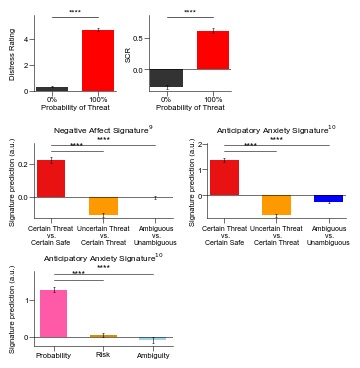

In [12]:
# ----------------------------
# Assemble SFig1 panels a-d
# ----------------------------

W_MM, H_MM = 90, 105
Sfig1_a_f = plt.figure(figsize=(W_MM / 25.4, H_MM / 25.4), facecolor="white")

outer = Sfig1_a_f.add_gridspec(
    nrows=3, ncols=1,
    left=0.10, right=0.98, bottom=0.12, top=0.92,
    hspace=0.7,
)

gs_top = outer[0].subgridspec(1, 3, wspace=0.4)    # a | b | brain
gs_mid = outer[1].subgridspec(1, 2, wspace=0.25)   # c | d
gs_bot = outer[2].subgridspec(1, 2, wspace=0.25)   # e | (empty)

# Upper row
ax_rating = Sfig1_a_f.add_subplot(gs_top[0, 0])
ax_scl    = Sfig1_a_f.add_subplot(gs_top[0, 1])
ax_brain  = Sfig1_a_f.add_subplot(gs_top[0, 2])
ax_brain.axis("off")

# Middle row
ax_Ceko = Sfig1_a_f.add_subplot(gs_mid[0, 0])
ax_Liu  = Sfig1_a_f.add_subplot(gs_mid[0, 1])

# Bottom row
ax_Liu_nonCat = Sfig1_a_f.add_subplot(gs_bot[0, 0])
# gs_bot[0, 1] left empty, or add another panel later


plot_certain_rating_panel(ax_rating, summ_rating, certain_colors,
                           p_value=p_Sfig1_a)
plot_certain_scl_panel(ax_scl, summ_scl, certain_colors,
                        p_value=p_Sfig1_b)
plot_Ceko_NE_panel(ax_Ceko, cat_summ_Ceko_NE, colors_cat,
                   p_1_vs_2=p_Sfig1_c_1_vs_2, p_1_vs_3=p_Sfig1_c_1_vs_3, add_contrasts=True)
plot_LiuBecker_panel(ax_Liu, cat_summ_LiuBecker_Amb, colors_cat,
                     p_1_vs_2=p_Sfig1_d_1_vs_2, p_1_vs_3=p_Sfig1_d_1_vs_3, add_contrasts=True)
plot_LiuBecker_nonCat_panel(ax_Liu_nonCat, summ_LiuBecker_Amb, colors_by_reg, 
                            p_prob_vs_risk=p_Sfig1_f_prob_vs_risk, p_prob_vs_amb=p_Sfig1_f_prob_vs_amb, add_contrasts=True)



Sfig1_a_f.align_ylabels([ax_rating, ax_Ceko, ax_Liu_nonCat])

plt.show()

save_figure(
    fig=Sfig1_a_f,
    out_dir=fig_out_dir,
    filename="SFig1_a_f",
    dpi=600, save_pdf=True, save_png=True,
    facecolor="white", bbox_inches="tight",
)